# A coral reef as a Potts model: tipping points and early warnings

A reef is a lattice of patches - healthy coral, bleached coral, bare rock, macroalgae -
each nudged by its neighbours and by the water temperature, exactly like spins in a
magnet. Statistical physics has a firm prediction about such systems: **models where every
patch feels every other (mean field) overstate how abrupt and irreversible a transition
is.** The classic coral-reef models are mean-field. This notebook switches the interaction
range and measures what happens.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
import figstyle
figstyle.apply()
import coral_model as cm

record = pd.read_excel('Coral temps.xlsx')
temps, observed = record['Temp'].values, record['Smooth'].values

## 1. Calibration: one real bleaching event, without steering

151 days of water temperature and bleaching from a reef in Western Australia. The original
model steered itself toward the observed bleaching ("nudge"); here it runs free. A model
that sits near a threshold must bleach *and* recover - a harder test than collapsing.

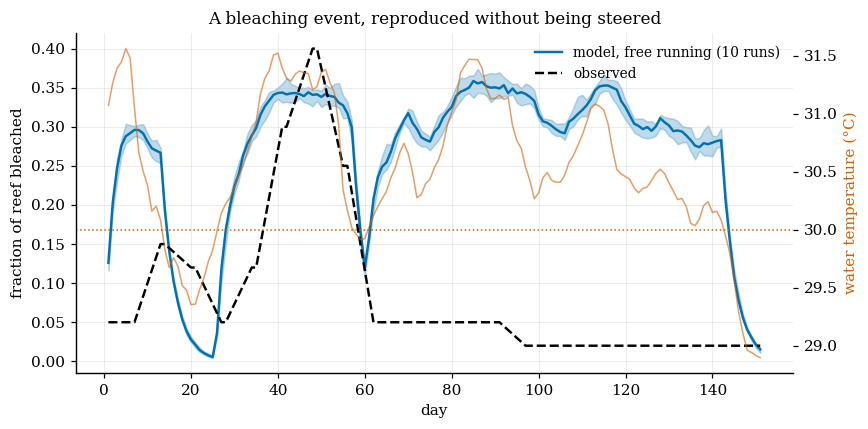

peak bleached: model 0.37, observed 0.40; end: model 0.02, observed 0.02


In [2]:
runs = [cm.run_record(temps, seed=k) for k in range(10)]
bleached = np.array([r[1] for r in runs])

fig, ax1 = plt.subplots(figsize=(8, 4))
days = np.arange(1, len(temps) + 1)
ax1.fill_between(days, np.percentile(bleached, 5, 0), np.percentile(bleached, 95, 0), color=figstyle.PALETTE[0], alpha=0.25)
ax1.plot(days, np.median(bleached, 0), color=figstyle.PALETTE[0], label='model, free running (10 runs)')
ax1.plot(days, observed, 'k--', label='observed')
ax1.set_xlabel('day')
ax1.set_ylabel('fraction of reef bleached')
ax2 = ax1.twinx()
ax2.plot(days, temps, color=figstyle.PALETTE[1], lw=1, alpha=0.6)
ax2.axhline(30, color=figstyle.PALETTE[1], ls=':', lw=1)
ax2.set_ylabel('water temperature (°C)', color=figstyle.PALETTE[1])
ax2.grid(False)
ax1.legend(loc='upper right')
ax1.set_title('A bleaching event, reproduced without being steered')
fig.tight_layout()
figstyle.save(fig, 'figures/fig1_calibration')
plt.show()
print(f"peak bleached: model {np.median(bleached.max(1)):.2f}, observed {observed.max():.2f}; "
      f"end: model {np.median(bleached[:, -1]):.2f}, observed {observed[-1]:.2f}")

## 2. Can the reef get stuck? Hysteresis against interaction range

Warm the water step by step, then cool it back. If the reef recovers along the same path,
the transition is reversible. If it stays degraded at temperatures where it was once
healthy, it has **hysteresis** - a tipping point that cannot be undone by reversing the
cause.

(The original model could not do this: its death rules needed heat stress above a cap it
could never reach, so coral never died. Mortality under prolonged stress, and macroalgae
held back by grazers - the feedback behind real reef collapse - were added; neither
changes the calibration above.)

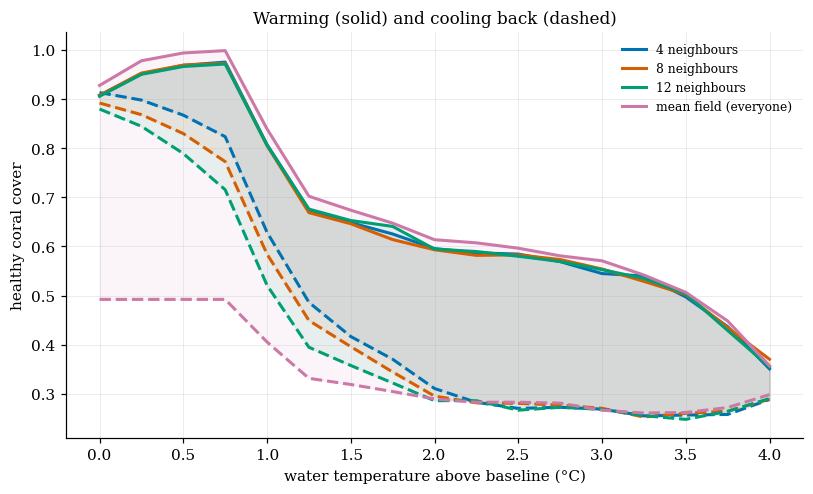

4 neighbours             hysteresis width 0.84
8 neighbours             hysteresis width 0.90
12 neighbours            hysteresis width 0.99
mean field (everyone)    hysteresis width 1.38


In [3]:
anomalies = np.round(np.arange(0, 4.01, 0.25), 2)
ranges = {'4 neighbours': 'nn1', '8 neighbours': 'nn2', '12 neighbours': 'nn3', 'mean field (everyone)': 'meanfield'}
loops = {}
for label, nb in ranges.items():
    ups, downs = zip(*[cm.hysteresis(anomalies, sweeps=60, neighbourhood=nb, seed=k) for k in range(3)])
    loops[label] = (np.mean(ups, 0), np.mean(downs, 0))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for (label, (up, down)), colour in zip(loops.items(), figstyle.PALETTE):
    ax.plot(anomalies, up, '-', color=colour, lw=2, label=label)
    ax.plot(anomalies, down, '--', color=colour, lw=2)
    ax.fill_between(anomalies, down, up, color=colour, alpha=0.08)
ax.set_xlabel('water temperature above baseline (°C)')
ax.set_ylabel('healthy coral cover')
ax.set_title('Warming (solid) and cooling back (dashed)')
ax.legend(fontsize=8)
fig.tight_layout()
figstyle.save(fig, 'figures/hero')
plt.show()

widths = {label: np.trapezoid(np.abs(up - down), anomalies) for label, (up, down) in loops.items()}
for label, w in widths.items():
    print(f"{label:24s} hysteresis width {w:.2f}")

**Every reef gets stuck - and mean field gets stuck worst.** Once heat kills enough coral,
algae take the space and grazers can no longer keep up, so cooling the water back does not
bring the coral back. The loop is widest when every patch feels the whole reef, as
statistical physics predicts: short-range interaction lets healthy patches survive
locally and reseed their neighbours, softening the collapse. Models that ignore space
make reefs look more fragile than spatially structured ones.

## 3. Does the speed of warming matter?

Warm to a peak at different rates, hold, then cool. If fast warming killed reefs that
slow warming spared at the same peak, alerts based on accumulated heat (NOAA's Degree
Heating Weeks) would have a blind spot.

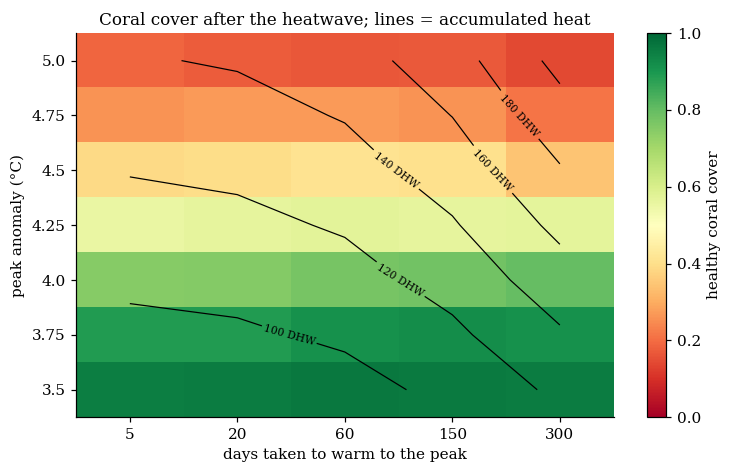

In [4]:
peaks = [3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0]
ramp_days = [5, 20, 60, 150, 300]
final = np.zeros((len(peaks), len(ramp_days)))
heat = np.zeros_like(final)
for i, p in enumerate(peaks):
    for j, d in enumerate(ramp_days):
        sched, cover, _ = cm.ramp(p, d, hold_days=240, recover_days=250, seed=1)
        final[i, j] = cover[-1]
        heat[i, j] = np.sum(np.maximum(sched - 1.0, 0)) / 7      # degree-heating-weeks above the bleaching threshold

fig, ax = plt.subplots(figsize=(7, 4.4))
im = ax.imshow(final, origin='lower', cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
cs = ax.contour(heat, colors='k', linewidths=0.8, levels=6)
ax.clabel(cs, fmt='%.0f DHW', fontsize=7)
ax.set_xticks(range(len(ramp_days))); ax.set_xticklabels(ramp_days)
ax.set_yticks(range(len(peaks))); ax.set_yticklabels(peaks)
ax.set_xlabel('days taken to warm to the peak')
ax.set_ylabel('peak anomaly (°C)')
ax.set_title('Coral cover after the heatwave; lines = accumulated heat')
fig.colorbar(im, label='healthy coral cover')
ax.grid(False)
fig.tight_layout()
figstyle.save(fig, 'figures/fig3_rate_map')
plt.show()

**Speed does not matter here - how hot it gets does.** The colour bands run flat across
the map: a reef warmed in five days ends up the same as one warmed over ten months. They
also cut *across* the heat contours, so the heat piled up during the warming does not
decide the outcome either - the temperature the reef is then held at does. The reef's
heat-stress memory lasts about a week, too short for a fast warming to overshoot it, so
there is no rate-induced tipping in this model: a clean negative answer, and a hint that
how hot a heatwave peaks, and for how long, matter more than how quickly it arrives.

## 4. Can collapse be seen coming?

Warm the reef slowly across its tipping point and watch two kinds of indicator: in time
(the variance and memory of coral cover - "critical slowing down") and in space (how
patchy the reef becomes). Only a spatial model can produce the second kind at all.

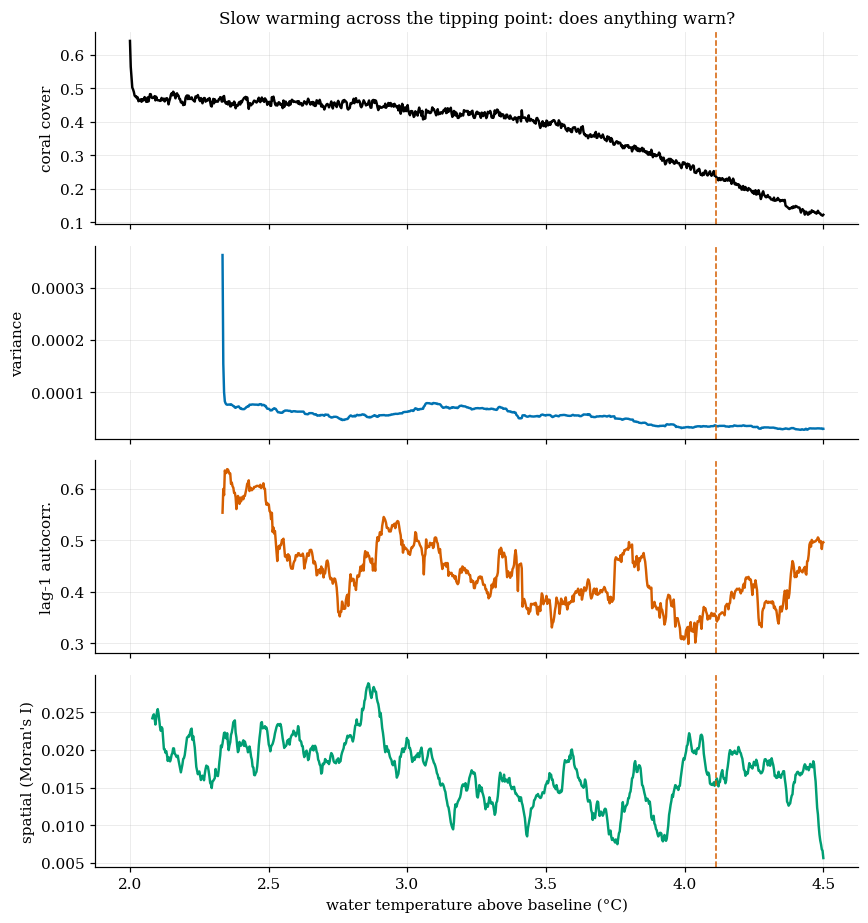

cover halves at +4.11 °C


In [5]:
reef = cm.Reef(seed=4, neighbourhood='nn1')
schedule = np.concatenate([np.linspace(2.0, 4.5, 900)])
cover, spatial_var, moran = [], [], []
for a in schedule:
    reef.step(reef.thresh - 1.0 + a)
    cover.append(reef.cover())
    h = np.nan_to_num(reef.healthy_map(), nan=0.0)
    blocks = h[:96, :96].reshape(12, 8, 12, 8).mean(axis=(1, 3))       # 8x8-cell blocks
    spatial_var.append(blocks[blocks > 0].var())
    z = h - h[reef.reef].mean()
    z[~reef.reef] = 0
    moran.append((z * (np.roll(z, 1, 0) + np.roll(z, 1, 1))).sum() / (2 * (z ** 2).sum()))
cover = np.array(cover)

def rolling(x, w=120, f=np.var):
    return np.array([f(x[max(0, i - w):i]) if i >= w else np.nan for i in range(len(x))])
def ac1(x):
    x = x - x.mean()
    return (x[1:] * x[:-1]).sum() / (x ** 2).sum()

detrended = cover - pd.Series(cover).rolling(60, center=True, min_periods=1).mean().values
collapse = int(np.argmax(cover < 0.5 * cover[:100].mean()))

fig, axes = plt.subplots(4, 1, figsize=(8, 8.5), sharex=True)
axes[0].plot(schedule, cover, 'k'); axes[0].set_ylabel('coral cover')
axes[1].plot(schedule, rolling(detrended), color=figstyle.PALETTE[0]); axes[1].set_ylabel('variance')
axes[2].plot(schedule, rolling(detrended, f=ac1), color=figstyle.PALETTE[1]); axes[2].set_ylabel('lag-1 autocorr.')
axes[3].plot(schedule, pd.Series(moran).rolling(30).mean(), color=figstyle.PALETTE[2]); axes[3].set_ylabel("spatial (Moran's I)")
for ax in axes:
    ax.axvline(schedule[collapse], color=figstyle.PALETTE[1], ls='--', lw=1)
axes[0].set_title('Slow warming across the tipping point: does anything warn?')
axes[-1].set_xlabel('water temperature above baseline (°C)')
fig.tight_layout()
figstyle.save(fig, 'figures/fig4_early_warning')
plt.show()
print(f"cover halves at +{schedule[collapse]:.2f} °C")

**Nothing warns - because there is nothing sudden to warn of.** Under slow warming the
reef slides down smoothly rather than flipping, and the classic early-warning signals
(rising variance and autocorrelation, growing patchiness) are built to detect an
approaching *jump*. Variance actually falls as cover falls. The tipping in this model shows
up on the way *back* - the hysteresis loops in section 2 - not as a warning on the way
down. Early-warning indicators are only as good as the kind of transition they are
pointed at.

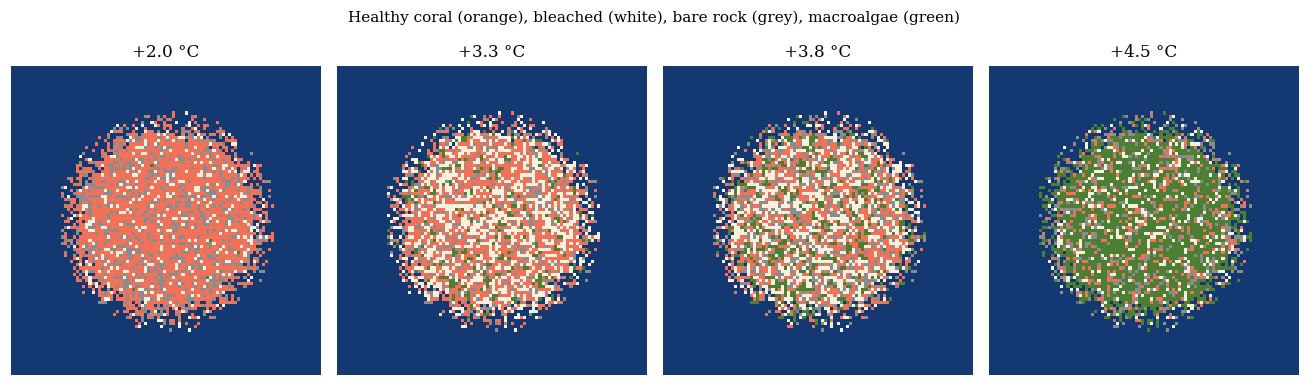

In [6]:
#snapshots of the reef through the collapse, for the README and the site
reef = cm.Reef(seed=4, neighbourhood='nn1')
snaps, temps_at = [], []
for i, a in enumerate(np.linspace(2.0, 4.5, 900)):
    reef.step(reef.thresh - 1.0 + a)
    if i in (0, 450, 650, 899):
        snaps.append(reef.image()); temps_at.append(a)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4))
for ax, img, a in zip(axes, snaps, temps_at):
    ax.imshow(img); ax.set_title(f"+{a:.1f} °C"); ax.axis('off')
fig.suptitle('Healthy coral (orange), bleached (white), bare rock (grey), macroalgae (green)', y=1.02, fontsize=10)
fig.tight_layout()
figstyle.save(fig, 'figures/fig2_reef_snapshots')
plt.show()